# Mental Health Risk Profiling using Survey Data

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    roc_curve
)

plt.style.use("default")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

os.makedirs("images", exist_ok=True)

## 1. Load Data

The original capstone used a large survey file with more than 600 variables. Earlier exploratory modeling compared Logistic Regression, Random Forest, and XGBoost. In that stage, XGBoost achieved the strongest benchmark ROC-AUC for depression and anxiety, but it also relied on a much broader feature space and was less suitable for an interpretable public-facing deployment. :contentReference[oaicite:2]{index=2}

For the final deployed version, I use a smaller, explicitly non-leaky feature set.

In [2]:
DATA_PATH = r"C:\Users\cheta\Downloads\2022-CSV\CSV\Data\pumf.csv"   # change if needed

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Raw shape:", df.shape)
df.head()

Raw shape: (9861, 602)


,PUMFID,GEODVPSZ,DHHGMS,DHHGAGE,GENDER,GEN_01,GEN_02A,GEN_08B,GEN_08C,GEN_02A1,GEN_02B,GEN_07,GEN_08,GEN_09,GEN_10,GENDHDI,GENGSWL,SCR_21,SCR_22,SCR_23,SCR_24,SCR_25A,SCR_25B,SCR_26A,SCR_26B,SCR_26C,SCR_29A,SCR_29B,SCR_29C,SCR_29D,SCR_29E,SCRDMEN,SCRDDEP,SCRDMIA,SCRDGAD,SCRDSOP,CCC_031,CCC_051,CCC_061,CCC_062,CCC_071,CCC_072,CCC_081,CCC_091,CCC_101,CCC_121,CCC_131,CCC_132,CCC_171A,CCC_251,CCC_261,CCC_280A,CCC280BA,CCCG28AE,CCC_290A,CCC290BA,CCC290BB,CCC290BC,CCC290BD,CCC_311,CCC_331,CCC_332,CCCG901,CCCF1,CCCDHBP,CCCDCNCR,CCCDSCZO,CCCDPSYC,HUPDPAD,PHSFPPA,IM_10L,IM_10M,IM_10O,IM_10AB,IM_10DE,IM_10FG,IM_10HI,IM_10JK,IM_10CN,PMH_01,PMH_02,PMH_03,PMH_04,PMH_05,PMH_06,PMH_07,PMH_08,PMH_09,PMH_10,PMH_11,PMH_12,PMH_13,PMH_14,PMHDHEM,PMHDLEM,PMHDHFU,PMHDLFU,PMHDCLA,PMHDSCR,STS_1,...,PNC_05CH,PNC_05CI,PNC_05CL,PNC_05DA,PNC_05DB,PNC_05DC,PNC_05DD,PNC_05DE,PNC_05DF,PNC_05DG,PNC_05DH,PNC_05DI,PNC_05DL,PNCG5D4D,PNCFH12,PNCDHCT,PNCDPNI,PNCDPNM,PNCDPNC,PNCDPNO,PNCDNEED,MHE_05A,MHE_05B,MHE_06,MHE_06A,MHE_06B,MHE_06C,MHE_06D,MHE_06E,MHE_06F,FMI_01A,FMI_02,SPS_01,SPS_02,SPS_03,SPS_04,SPS_05,SPS_06,SPS_07,SPS_08,SPS_09,SPS_10,SPSDCON,SPSDATT,SPSDGUI,SPSDALL,SPSDINT,SPSDWOR,NSI_01,NSI_02,NSI_03,NSI_04,NSI_05,NSIDSC,CEX_01,CEX_02,CEX_03,CEX_04,CEX_05,CEX_06,CEX_07,CEXDNUM,SPI_01,LMAM_01,LMAM_02,LMAMG03,LBSDWSS,LBSGSOC,WST_401,WST_402,WST_403,WST_404,WST_405,WST_406,WST_407,WST_408,WST_409,WST_410,WST_411,WST_412,WST_413,WSTDSKI,WSTDAUT,WSTDPSY,WSTDJIN,WSTDPHY,WSTDSOC,WSTDJST,SORLGBTS,SDCFIMM,SDCGRES,SDCGVVM,SDCDVFLA,EDU_05,INCDVP19,INCDVP20,INCDVHH,DABTIPPE,DNBTIPPE,WTS_M
0,615402.0,3.0,1.0,7.0,1.0,2.0,3.0,2.0,3.0,3.0,8.0,3.0,1.0,3.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,6.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,3.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,6.0,6.0,2.0,6.0,6.0,6.0,6.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,0.0,1.0,0.0,1.0,56.0,2.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,96.0,2.0,0.0,1.0,1.0,1.0,1.0,1.0,2.0,6.0,6.0,996.0,996.0,996.0,996.0,996.0,996.0,1.0,4.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,30.0,6.0,6.0,6.0,6.0,6.0,2.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,2.0,1.0,6.0,96.0,1.0,2.0,3.0,2.0,2.0,3.0,2.0,2.0,1.0,5.0,2.0,4.0,2.0,2.0,2.0,5.0,2.0,4.0,0.0,0.0,3.0,0.83,2.0,2.0,6.0,6.0,2.0,3.0,14.0,14.0,15.0,3.0,1.0,4372.02
1,615403.0,4.0,3.0,2.0,2.0,4.0,3.0,4.0,4.0,3.0,8.0,4.0,1.0,4.0,2.0,1.0,2.0,1.0,6.0,6.0,1.0,2.0,6.0,2.0,1.0,1.0,2.0,2.0,6.0,6.0,6.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,6.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,6.0,6.0,2.0,6.0,6.0,6.0,6.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,3.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,3.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,0.0,1.0,0.0,1.0,59.0,1.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,96.0,1.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,6.0,6.0,996.0,996.0,996.0,996.0,996.0,996.0,2.0,6.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0,36.0,8.0,6.0,7.0,8.0,7.0,1.0,2.0,2.0,3.0,2.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,4.0,1.0,6.0,96.0,1.0,3.0,2.0,3.0,2.0,2.0,1.0,4.0,2.0,2.0,4.0,4.0,5.0,2.0,2.0,6.0,4.0,7.0,1.0,3.0,6.0,1.50,2.0,2.0,6.0,6.0,2.0,6.0,5.0,5.0,13.0,10.0,9.0,2711.23
2,615404.0,4.0,1.0,6.0,1.0,2.0,3.0,3.0,3.0,2.0,7.0,3.0,1.0,4.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,6.0,2.0,7.0,2.0,2.0,2.0,6.0,6.0,6.0,2.0,2.0,2.0,9.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,6.0,6.0,2.0,6.0,6.0,6.0,6.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,4.0,1.0,2.0,1.0,1.0,1.0,6.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,60.0,3.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,96.0,2.0,0.0,1.0,1.0,1.0,1.0,1.0,2.0,6.0,6.0,996.0,996.0,996.0,996.0,996.0,996.0,2.0,6.0,2.0,2.0,2.0,1.0,2.0,2.0,3.0,1.0,2.0,2.0,31.0,7.0,7.0,6.0,5.0,6.0,7.0,9.0,9.0,9.0,9.0,99.0,1.0,4.0,2.0,1.0,1.0,1.0,2.0,2.0,3.0,1.0,6.0,96.0,1.0,4.0,2.0,2.0,2.0,2.0,2.0,7.0,2.0,1.0,2.0,4.0,4.0,2.0,1.0,5

## 2. Target Construction

The depression screener target is based on `SCRDDEP`, where:

- `1` = screened positive  
- `2` = screened negative  


In [4]:
df = df[df["SCRDDEP"].isin([1, 2])].copy()
df["dep_target"] = df["SCRDDEP"].replace({1: 1, 2: 0}).astype(int)

print("=== TARGET COUNTS ===")
print(df["dep_target"].value_counts(dropna=False))

=== TARGET COUNTS ===
dep_target
1    5830
0    3840
Name: count, dtype: int64


## 3. Final Non-Leaky Feature Set

The final model uses a deliberately conservative set of variables that are realistic to collect in an interactive tool and do not directly encode the screening outcome. These features capture demographics, lifestyle, social support, stress, coping, and functioning.


In [6]:
features = [
    "DHHGAGE",   # age grouped
    "GENDER",    # gender
    "EDU_05",    # education
    "LMAM_01",   # worked last week
    "PHSFPPA",   # physical activity flag
    "SPSDCON",   # social support score
    "GEN_02B",   # life satisfaction (0-10)
    "GEN_07",    # perceived life stress
    "STS_1",     # handle unexpected problems
    "STS_4",     # can count on people to deal with stress
    "NSIDSC",    # negative social interactions
    "DASGSCR"    # disability score
]

df = df[features + ["dep_target"]].copy()

# Invert social support direction so higher values correspond to lower support / higher risk
df["SPSDCON"] = 100 - df["SPSDCON"]

## 4. Missing Value Handling

Common survey nonresponse codes are replaced with missing values. Life satisfaction is additionally constrained to its valid range of 0 to 10.

In [7]:
missing_codes = {6, 7, 8, 9, 96, 97, 98, 99, 996, 997, 998, 999}

for col in features:
    df[col] = df[col].replace(list(missing_codes), np.nan)

df.loc[~df["GEN_02B"].between(0, 10, inclusive="both"), "GEN_02B"] = np.nan

df = df.dropna(subset=["dep_target"]).copy()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (9670, 13)


## 5. Train/Test Design and Preprocessing

Categorical survey codes are one-hot encoded, while continuous variables are median-imputed and scaled. The final model is a calibrated logistic regression classifier.

In [8]:
categorical_features = [
    "DHHGAGE",
    "GENDER",
    "EDU_05",
    "LMAM_01",
    "PHSFPPA",
    "GEN_07",
    "STS_1",
    "STS_4"
]

numeric_features = [
    "SPSDCON",
    "GEN_02B",
    "NSIDSC",
    "DASGSCR"
]

X = df[features]
y = df["dep_target"]

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features)
    ]
)

base_model = LogisticRegression(
    max_iter=500,
    class_weight="balanced"
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", CalibratedClassifierCV(base_model, method="sigmoid", cv=3))
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 6. Model Training and Evaluation

In [10]:
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.50).astype(int)

print("=== TEST PERFORMANCE (FINAL threshold = 0.50) ===")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

=== TEST PERFORMANCE (FINAL threshold = 0.50) ===
ROC-AUC:  0.7522
Accuracy: 0.6908

Classification report:
              precision    recall  f1-score   support

           0     0.6316    0.5312    0.5771       768
           1     0.7205    0.7959    0.7563      1166

    accuracy                         0.6908      1934
   macro avg     0.6760    0.6636    0.6667      1934
weighted avg     0.6852    0.6908    0.6851      1934



## 7. Target Distribution Plot

This plot shows the cleaned depression screening distribution used for the final model.

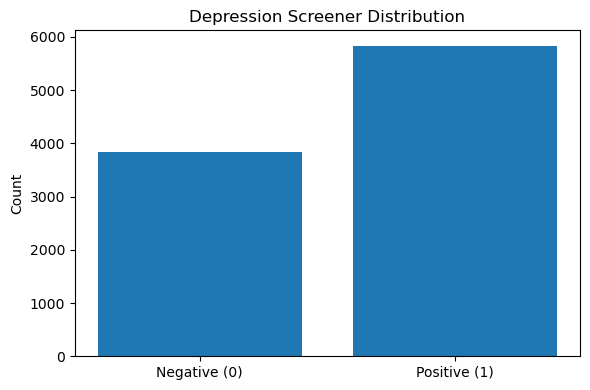

In [11]:
target_counts = y.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Negative (0)", "Positive (1)"], [target_counts[0], target_counts[1]])
plt.title("Depression Screener Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("images/target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. ROC Curve

The earlier capstone benchmark compared multiple models and showed strong ROC performance across Logistic Regression, Random Forest, and XGBoost, with XGBoost performing best. :contentReference[oaicite:7]{index=7}

For the final GitHub notebook, I show the ROC curve of the final calibrated logistic model used in deployment.

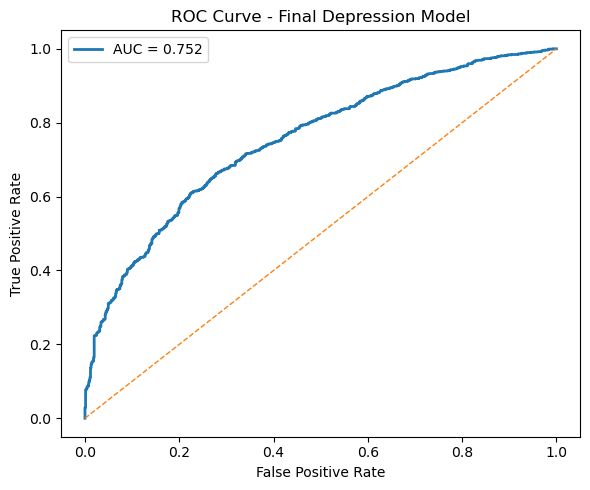

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Depression Model")
plt.legend()
plt.tight_layout()
plt.savefig("images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Synthetic Profile Validation

A key part of the final refinement was testing the model on manually constructed user profiles. This was used to verify that the model responds logically across low-risk, moderate-risk, and high-risk scenarios.


In [13]:
profiles = [
    {
        "profile_name": "Stable highly supported adult",
        "DHHGAGE": 7,
        "GENDER": 1,
        "EDU_05": 7,
        "LMAM_01": 1,
        "PHSFPPA": 1,
        "SPSDCON": 85,
        "GEN_02B": 9,
        "GEN_07": 1,
        "STS_1": 1,
        "STS_4": 1,
        "NSIDSC": 1,
        "DASGSCR": 5
    },
    {
        "profile_name": "Young supported student",
        "DHHGAGE": 2,
        "GENDER": 2,
        "EDU_05": 4,
        "LMAM_01": 6,
        "PHSFPPA": 1,
        "SPSDCON": 75,
        "GEN_02B": 8,
        "GEN_07": 2,
        "STS_1": 2,
        "STS_4": 2,
        "NSIDSC": 2,
        "DASGSCR": 8
    },
    {
        "profile_name": "Moderate pressure worker",
        "DHHGAGE": 5,
        "GENDER": 1,
        "EDU_05": 6,
        "LMAM_01": 1,
        "PHSFPPA": 1,
        "SPSDCON": 60,
        "GEN_02B": 6,
        "GEN_07": 3,
        "STS_1": 3,
        "STS_4": 3,
        "NSIDSC": 4,
        "DASGSCR": 15
    },
    {
        "profile_name": "Unemployed low activity profile",
        "DHHGAGE": 6,
        "GENDER": 2,
        "EDU_05": 2,
        "LMAM_01": 2,
        "PHSFPPA": 2,
        "SPSDCON": 35,
        "GEN_02B": 4,
        "GEN_07": 4,
        "STS_1": 4,
        "STS_4": 4,
        "NSIDSC": 7,
        "DASGSCR": 28
    },
    {
        "profile_name": "High stress but still supported",
        "DHHGAGE": 5,
        "GENDER": 1,
        "EDU_05": 6,
        "LMAM_01": 1,
        "PHSFPPA": 1,
        "SPSDCON": 80,
        "GEN_02B": 6,
        "GEN_07": 5,
        "STS_1": 3,
        "STS_4": 2,
        "NSIDSC": 4,
        "DASGSCR": 18
    },
    {
        "profile_name": "Low satisfaction weak coping",
        "DHHGAGE": 3,
        "GENDER": 2,
        "EDU_05": 4,
        "LMAM_01": 2,
        "PHSFPPA": 2,
        "SPSDCON": 45,
        "GEN_02B": 2,
        "GEN_07": 4,
        "STS_1": 5,
        "STS_4": 4,
        "NSIDSC": 8,
        "DASGSCR": 24
    },
    {
        "profile_name": "Social isolation older adult",
        "DHHGAGE": 8,
        "GENDER": 1,
        "EDU_05": 2,
        "LMAM_01": 6,
        "PHSFPPA": 2,
        "SPSDCON": 20,
        "GEN_02B": 3,
        "GEN_07": 4,
        "STS_1": 4,
        "STS_4": 5,
        "NSIDSC": 9,
        "DASGSCR": 35
    },
    {
        "profile_name": "Young conflict-heavy profile",
        "DHHGAGE": 1,
        "GENDER": 2,
        "EDU_05": 2,
        "LMAM_01": 6,
        "PHSFPPA": 2,
        "SPSDCON": 25,
        "GEN_02B": 1,
        "GEN_07": 5,
        "STS_1": 5,
        "STS_4": 5,
        "NSIDSC": 11,
        "DASGSCR": 38
    },
    {
        "profile_name": "High strain compressed profile",
        "DHHGAGE": 4,
        "GENDER": 1,
        "EDU_05": 2,
        "LMAM_01": 2,
        "PHSFPPA": 2,
        "SPSDCON": 15,
        "GEN_02B": 0,
        "GEN_07": 5,
        "STS_1": 5,
        "STS_4": 5,
        "NSIDSC": 12,
        "DASGSCR": 45
    },
    {
        "profile_name": "Resilient moderate worker",
        "DHHGAGE": 6,
        "GENDER": 2,
        "EDU_05": 7,
        "LMAM_01": 1,
        "PHSFPPA": 1,
        "SPSDCON": 70,
        "GEN_02B": 7,
        "GEN_07": 3,
        "STS_1": 2,
        "STS_4": 2,
        "NSIDSC": 3,
        "DASGSCR": 10
    }
]

profiles_df = pd.DataFrame(profiles)

# Apply same support-direction fix used in training
profiles_df["SPSDCON"] = 100 - profiles_df["SPSDCON"]

profile_probs = model.predict_proba(profiles_df[features])[:, 1]
profile_preds = (profile_probs >= 0.50).astype(int)

profiles_df["depression_screen_risk"] = profile_probs
profiles_df["predicted_class_0_5"] = profile_preds
profiles_df = profiles_df.sort_values("depression_screen_risk", ascending=False)

profiles_df[["profile_name", "depression_screen_risk", "predicted_class_0_5"]]

,profile_name,depression_screen_risk,predicted_class_0_5
8,High strain compressed profile,0.998196,1
7,Young conflict-heavy profile,0.996704,1
5,Low satisfaction weak coping,0.993881,1
6,Social isolation older adult,0.984145,1
3,Unemployed low activity profile,0.982020,1
4,High stress but still supported,0.905753,1
2,Moderate pressure worker,0.853687,1
9,Resilient moderate worker,0.743571,1
1,Young supported student,0.668040,1
0,Stable highly supported adult,0.365204,0


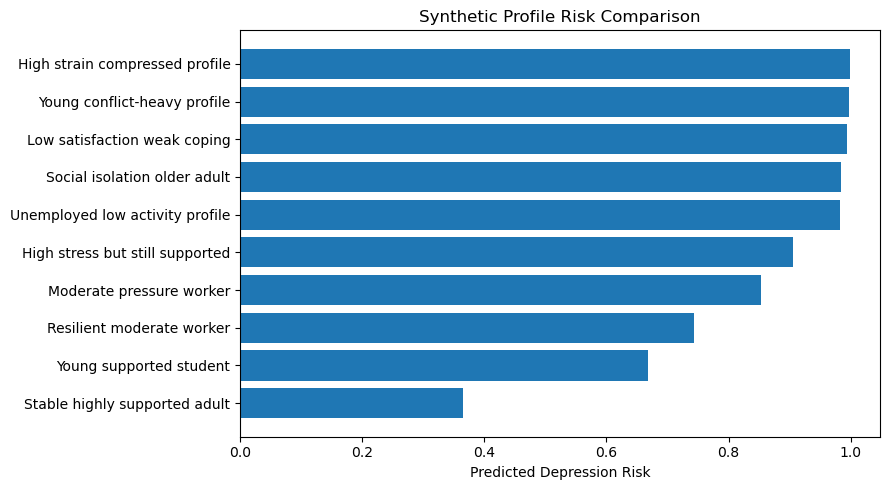

In [14]:
plt.figure(figsize=(9, 5))
plt.barh(profiles_df["profile_name"], profiles_df["depression_screen_risk"])
plt.xlabel("Predicted Depression Risk")
plt.title("Synthetic Profile Risk Comparison")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("images/profile_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Global Feature Importance

The final logistic model makes it possible to inspect coefficient-based global feature importance. In the final capstone refinement, the largest absolute coefficients were associated with:

- negative social interaction (`NSIDSC`)
- disability/functioning (`DASGSCR`)
- life satisfaction (`GEN_02B`)
- high stress (`GEN_07`)
- poor coping (`STS_1`)

This interpretability was one of the main reasons for choosing the final calibrated logistic regression model over more complex alternatives.

In [15]:
calibrated_model = model.named_steps["classifier"]
base_model = calibrated_model.calibrated_classifiers_[0].estimator

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefs = base_model.coef_[0]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

importance_df["abs_coef"] = importance_df["coefficient"].abs()
importance_df = importance_df.sort_values("abs_coef", ascending=False)

importance_df.head(15)

,feature,coefficient,abs_coef
33,num__NSIDSC,1.466761,1.466761
34,num__DASGSCR,1.197107,1.197107
32,num__GEN_02B,-1.178387,1.178387
20,cat__GEN_07_5.0,0.959574,0.959574
25,cat__STS_1_5.0,0.874078,0.874078
16,cat__GEN_07_1.0,-0.722788,0.722788
19,cat__GEN_07_4.0,0.506539,0.506539
21,cat__STS_1_1.0,-0.456017,0.456017
30,cat__STS_4_5.0,0.449074,0.449074
24,cat__STS_1_4.0,0.433923,0.433923


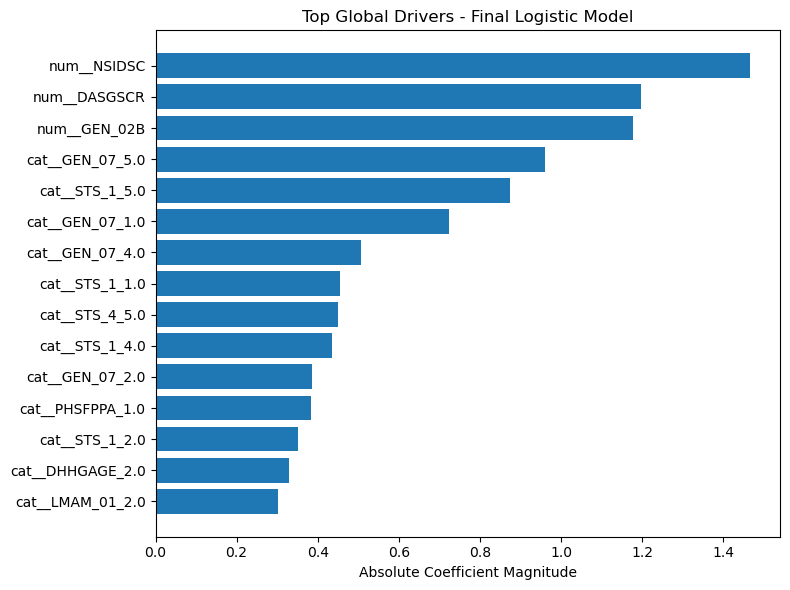

In [16]:
plot_df = importance_df.head(15).sort_values("abs_coef", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["abs_coef"])
plt.xlabel("Absolute Coefficient Magnitude")
plt.title("Top Global Drivers - Final Logistic Model")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()